# BEE 4750 Homework 2: Systems Modeling and Simulation

**Name**: William Natcharian

**ID**: Wrn25

> **Due Date**
>
> Thursday, 09/25/25, 9:00pm

## Overview

### Instructions

-   Problem 1 asks you to draw a systems diagram and identify the type
    of a feedback.
-   Problem 2 asks you to model contaminant concentrations in a river
    and use simulation to compare the concentrations to a regulatory
    standard.
-   Problem 3 asks you to explore the implications of an ice-albedo
    feedback in the Earth’s climate system by understanding the
    equilibria of the modeled system and their stabilities.

### Load Environment

The following code loads the environment and makes sure all needed
packages are installed. This should be at the start of most Julia
scripts.

In [7]:
import Pkg
Pkg.activate(@__DIR__)
Pkg.instantiate()
Pkg.add("GraphRecipes")

  Activating project at `~/Desktop/4750 Cloned Repositories/hw2-will-wrn25`
   Resolving package versions...
  No Changes to `~/Desktop/4750 Cloned Repositories/hw2-will-wrn25/Project.toml`
  No Changes to `~/Desktop/4750 Cloned Repositories/hw2-will-wrn25/Manifest.toml`


In [9]:
using Plots
using LaTeXStrings
using CSV
using DataFrames
using Roots

#Adding to use graphplot to create diagram for Problem 1
using Random
using GraphRecipes
using LaTeXStrings
#using Distributions

## Problems (Total: 30 Points)

### Problem 1 (5 points)

Draw a systems diagram for the relationship between global mean
temperature, atmospheric CO<sub>2</sub> concentrations, and ocean
CO<sub>2</sub> concentrations. What are the signs of the interactions
between these components and why? What does this suggest about the
overall feedback between temperature and the ocean carbon cycle?

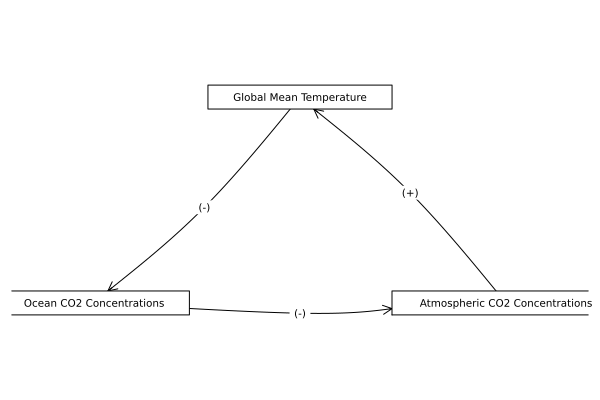

In [10]:
A = [0 1 0;
    0 0 1;
    1 0 0]

names = ["Global Mean Temperature", "Ocean CO2 Concentrations", "Atmospheric CO2 Concentrations"]
edge_labels = Dict((1, 2) => "(-)", (2, 3) => "(-)", (3,1) => "(+)")
shapes=[:rect, :rect, :rect]
xpos = [0, -1, 1]
ypos = [1, 0, 0]

p = graphplot(A, names=names,edgelabel=edge_labels, markersize=0.1, markershapes=shapes, markercolor=:white, x=xpos, y=ypos)
display(p)

--> Description of code: The code I used to create the diagram above is a modified version of the code that I used in Hw1 Problem 2.1: I use graphplot() to format the boxes representing our components. And I use the matrix A to describe which direction the arrows should point in, to accurately depict the cyclic nature of this diagram.

--> Description of diagram: A (+) connecting two boxes means that as the first component increases, the following component also increases. While a (-) connecting two boxes means that as the first component increases, the following component decreases (and vice versa). 

--> Component interactions: As the global mean temperature increases, the Ocean CO2 concentration decreases because CO2 solubility in water decreases as temperature rises. Then as the ocean CO2 conecntration decreases, the atmospheric CO2 concentration increases because the CO2 leaves the ocean and enters the air. Then as atmospheric CO2 concentrations increase, the global mean temperatures will increase due to a variety of effects, but primarily the greenhouse effect. That is, higher concentrations of CO2 end up reflecting radiated heat back towards the earth, trapping it within the Earth system for longer, thereby increasing the mean global temperature.

--> Overall this process describes a positive feedback loop for the global mean temperature. As the temperature increases, it eventually leads to further increases in the temperature. 

> **Tip**
>
> Think about Henry’s law for CO<sub>2</sub>.

### Problem 2 (15 points)

A river which flows at 10 km/d is receiving discharges of wastewater
contaminated with CRUD from two sources which are 15 km apart, as shown
in the Figure below. CRUD decays exponentially in the river at a rate of
0.36 $\mathrm{d}^{-1}$ and is deposited by the atmosphere along the
river at a rate of 54 kg/km/d. 

<figure>
<img src="attachment:figures/river_diagram.png"
alt="Schematic of the river system in Problem 2" />
<figcaption aria-hidden="true">Schematic of the river system in Problem
2</figcaption>
</figure>

#### Problem 2.1

Draw a systems diagram with the relevant control volume(s) denoted and
any relevant in/out-flows between these boxes. How did you decide how
many boxes were needed?

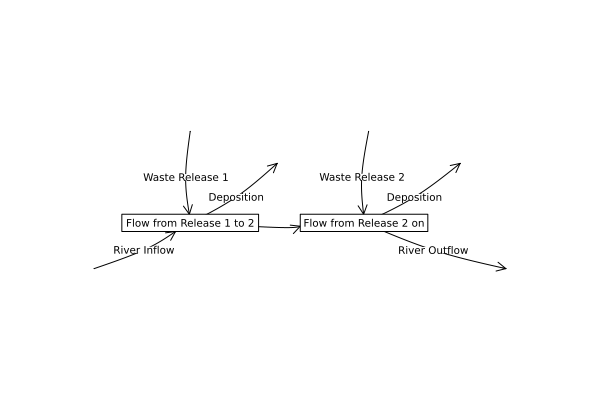

In [31]:
A = [0 0 1 0 0 0 0 0 0 0;
    0 0 1 0 0 0 0 0 0 0;
    0 0 0 1 0 0 1 0 0 0;
    0 0 0 0 0 1 0 1 0 0;
    0 0 0 1 0 0 0 0 0 0;
    0 0 0 0 0 0 0 0 0 0;
    0 0 0 0 0 0 0 0 0 0;
    0 0 0 0 0 0 0 0 0 0;
    0 0 0 0 0 0 0 0 0 0;
    0 0 0 0 0 0 0 0 0 0]

names = ["", "", "Flow from Release 1 to 2", "Flow from Release 2 on", "", "", "", "", "9", "10"]
edge_labels = Dict((1, 3) => "Waste Release 1", (2, 3) => "River Inflow", (5,4) => "Waste Release 2", (3,4) => "", (4,6) => "River Outflow", (3,7) => "Deposition", (4,8) => "Deposition")
shapes=[:circle, :circle, :rect, :rect, :circle, :circle, :circle, :circle, :circle, :circle]
xpos = [-0.95, -2, -0.95, 0.95, 1, 2.5, 0, 2]
ypos = [1, -0.5, 0, 0, 1, -0.5, 0.65, 0.65]

p1 = graphplot(A, names=names,edgelabel=edge_labels, markersize=0.35, markershapes=shapes, markercolor=:white, x=xpos, y=ypos)
display(p1)

--> The diagram above depicts two control volumes; one containing the river flow from waste release 1 to right before waste release 2; and the other contains the river flow from waste release 2 and on. The first control volume extends for $x=0km$ to $x=15km$, and the the second control volume extends from $x=15km$ to as far downstream as we wish to analyze.

--> The diagram has two control volumes instead of just one because the concentration of CRUD in the riverflow changes in a fundamentally different way before Waste Release 2 is connected to it, than what happens after it. The total volume of water in the river in $m^3/d$ is different between the two control volumes, meaning that if we tried to only use one, we would be losing significant information and introducing inaccuracies in our solutions.

-->For ease of formatting I did not show that the concentration decays within each control volume at a rate of $0.36/d$.

--> For ease of formatting I did not add the mathematical equations and numerical values associated with each inlet/outlet in the diagram above, so I will describe them here: 

- River Inflow: $Q_0 = 250,000m^3/d$, $C_0 = 0.5kg/(1000m^3)$

- Waste Release 1: $Q_{w1} = 40,000m^3/d$, $C_{w1} = 9kg/(1000m^3)$

- Deposition to Control Volume 1: $54kg/km/d$

- Decay in Control Volume 1: $0.36/d$

- Waste Release 2: $Q_{w2} = 60,000m^3/d$, $C_{w2} = 7kg/(1000m^3)$

- Deposition to Control Volume 2:

- Decay in Control Volume 2: $0.36/d$


--> Description of code: The code I used to create the diagram above is a modified version of the code that I used in Hw1 Problem 2.1: I use graphplot() to format the boxes representing our components. And I use the matrix A to describe which direction the arrows should point in.


#### Problem 2.2

Develop a model for the concentration of CRUD downriver by formulating
and solving the appropriate differential equation(s) analytically.

> **Tip**
>
> Formulate your model in terms of distance downriver, rather than
> leaving it in terms of time from discharge.

**Differential Equations:** 

$U*\frac{dC_1}{dx} = \frac{S_{dep}*U}{Q_1} - kC_1$

$U*\frac{dC_2}{dx} = \frac{S_{dep}*U}{Q_2} - kC_2$

- Where $S_{dep}$ is the deposition from the atmosphere = $(54kg/km/d)$, 

- $Q_1$ is the total volumetric flow just inside the first control volume = $(250,000m^3/d + 40,000m^3/d)$

- $Q_2$ is the total volumetric flow just inside the second control volume = $(290,000m^3/d + 60,000m^3/d)$

- $k$ is the decay rate = $0.36/day$

- $U$ is the river velocity = $10km/d$

- $x$ is the distance along the river in $km$

- $C_1(x)$ is the concentration of CRUD in the water at a certain point along the river in $kg/(1000m^3)$ between the two waste releases: $0km\leq x<15km$

- $C_2(x)$ is the concentration of CRUD in the water at a certain point along the river in $kg/(1000m^3)$ after the second waste releases: $x \geq 15km$



**Description of the Equations:** 
- $C$ has units of $\frac{kg}{(1000m^3)}$, $U$ has units of $\frac{km}{d}$, $x$ is in terms of $km$, so $\frac{dC}{dx}$ has units of $\frac{kg}{(1000m^3*km)}$. This means that we want each component on the RHS of the differential equations to have units of $\frac{kg}{1000m^3*d}$. This is why we multiply the deposition component by $U$ and divide it by $Q$, and why we multiply the decay component by $C$.

**Solutions:** 
- These are First-Order Linear ODE's so we can solve them analytically:

$C_1(x) = \frac{S_{dep}U}{Q_1k}*(1-e^{-\frac{k}{U}x})+C_{x=0}*e^{-\frac{k}{U}x}$ |  ($0km\leq x<15km$)

$C_2(x) = \frac{S_{dep}U}{Q_2k}*(1-e^{-\frac{k}{U}x})+C_{x=15}*e^{-\frac{k}{U}x}$ | ($x \geq 15km$)

- Above are the analytical solutions for our two control volumes.
- Where $C_{x=0}$ is the concentration of the first control volume at $x=0km$. We are assuming the river inflow and Waste Release 1 mix instantaneously at that point, so $C_{x=0} = 1.67kg/(1000m^3)$
- And $C_{x=15}$ is the concentration of the second control volume at $x=15km$. We assuming the flow from Waste Release 2 mixes with the river instantaneously at that point, so to find $C_{x=15}$ numerically, we must numerically solve the first ODE at $x=15km$ first.

#### Problem 2.3

Determine if the system in compliance with a regulatory limit of
$2.3\ \text{kg}/(1000 \text{m}^3)$. You can do this analytically or
computationally.

--> To solve this problem, we must use numerical values to determine if the deposition rate is higher than the decay rate. If it is not, then we can calculate how low the concentration gets to by $x = 15km$ where the influx from the second waste release should maximize the concentration over the whole system. If that maximum concentration is higher than $2.3kg/(1000m^3)$ then the system will not be in compliance. Otherwise if the deposition rate of CRUD from the atmosphere is higher than the decay rate, then we know the system will inevitably not be in compliance at a certain point since the concentration will continuously increase.

--> The initial concentration as the river inflow and Waste Release 1 mix is $C_{x=0} = 1.67kg/(1000m^3)$, which is already very close to the regulatory limit, so it is fairly possible that it will be non-compliant at some point.

**Calculations:**
- $\frac{S_{dep}U}{Q_1k} = 5.17kg/(1000m^3)$
- $\frac{k}{U} = .036/km$
- $C_{x=0} = 1.67kg/(1000m^3)$
- $C_{x=15}$ can be found after solving $C_1(x)$ at $x=15$, if needed

Inputting those values into the analytical solution for our first control volume: 

$C_1(x) = 5.17(1-e^{-.036x}) + 1.67e^{-0.036x}$

--> $C_1(15km) = 3.13 kg/(1000m^3)$

- This calculation shows that from $x=0km$ to $x=15km$, the rate of decay was smaller than the rate of deposition, so the initial concentration of CRUD increased from a value of $1.67kg/(1000m^3)$ to $3.13 kg/(1000m^3)$, which exceeds the regulatory limit of $2.3 kg/(1000m^3)$.

- This means the system is not in compliance with the regulatory limit, in both control volumes.

### Problem 3 (10 points)

In class, we discussed the ice-albedo feedback and its possible
influence on melting the hypothesized [“Snowball
Earth”](https://en.wikipedia.org/wiki/Snowball_Earth). In this problem,
we’ll introduce a simple model of the Earth’s energy balance with
includes this feedback and examine the stability of the climate.

This simple model of the energy balance (averaged over the entire
planet) is:

<span id="eq-climate">$$
\underbrace{C\frac{dT}{dt}}_{\text{change in heat}} = \underbrace{\frac{(1-\alpha)S}{4}}_{\text{incoming radiation}} - \underbrace{(A - BT)}_{\text{outgoing radiation}} + \underbrace{a\ln \left(\frac{[CO_2]}{[CO_2]_{PI}}\right)}_{\text{greenhouse effect}},
 \qquad(1)$$</span>

where:

-   $T$ is the Earth’s global mean temperature (in $^\circ\text{C}$);
-   $C$ is the heat capacity of the atmosphere and shallow ocean, taken
    to be $51\ \text{J}/\text{m}^2/^\circ\text{C}$;
-   $\alpha$ is the planetary albedo, or the fraction of incoming
    radiation reflected by the Earth, which has a present-day value of
    approximately 0.3;
-   $S$ is the solar constant, or the amount of solar radiation received
    by the Earth averaged over area, which has a present-day value of
    $1368\ \text{W}/\text{m}^2$ but during the Neoproteorozoic Era had a
    value of $1272\ \text{W}/\text{m}^2$ (this is divided by four
    because the Earth is a sphere but $S$ is the radiation captured by a
    disc with radius equal to that of the Earth);
-   $A$ and $B$ are coefficients from the linearization of outgoing
    radiation physics, and have corresponding values
    $B=-1.3\ \text{W}/\text{m}^2/^\circ\text{C}$ (estimated from a
    number of lines of evidence about the sensitivity of outgoing
    radiation to temperature; this is negative due to a sign convention
    about the direction of incoming vs. outgoing radiation) and
    $A=221.2\ \text{W}/\text{m}^2$ (estimated by assuming the
    pre-industrial temperature of $14^\circ\text{C}$ was stable without
    anthropogenic greenhouse gas emissions).

We will ignore the greenhouse effect term as we are considering the
Earth system well before humans were around.

#### Problem 3.1

Discretize the climate model
(<a href="#eq-climate" class="quarto-xref">Equation 1</a>) using forward
Euler integration and a time step of $\Delta t = 1$ yr.

For the following equation:

$C\frac{dT}{dt} = \frac{(1-\alpha)S}{4} - (A-BT)$

The discretized version of this model at $\Delta t = 1$ yr is as follows:

$T(t + \Delta t) = T(t) + \frac{\Delta t}{C}*[\frac{(1-\alpha)S}{4} -A +B*T(t)]$

#### Problem 3.2

Rather than assuming a constant value for the albedo $\alpha$, we will
represent the ice-albedo feedback by letting $\alpha$ depend on $T$:

$$\alpha(T) = 
    \begin{cases} 
        \alpha_i & \quad \text{if } T \leq -10^\circ \text{C} \\
        \alpha_i + (\alpha_0 - \alpha_i)((T+10) / 20) & \quad \text{if } -10^\circ \text{C} \leq T \leq 10^\circ \text{C} \\
        \alpha_0 & \quad \text{if } T \geq 10^\circ \text{C}.
    \end{cases}$$

Let $\alpha_i = 0.5$ and $\alpha_0 = 0.3$. Simulate the simple climate
model using the Neoprotereozoic value of $S$ with temperature-varying
albedo for initial values of $T$ spanning
$-60^\circ\text{C} \leq T_0 \leq 30^\circ\text{C}$ over a period of 200
years. Plot the temperature trajectories. How many equilibria are there
and what are their stabilities?

--> Now that $\alpha$ depends on $T$ for $-10°C \leq T \leq 10°C$, our discretization model will change slightly for that temperature range:

$T(t + \Delta t) = T(t) + \frac{\Delta t}{C}*[\frac{S}{4}(1-(\alpha _i + (\alpha _0 - \alpha _i)(\frac{T(t)+10}{20}))) -A +B*T(t)]$

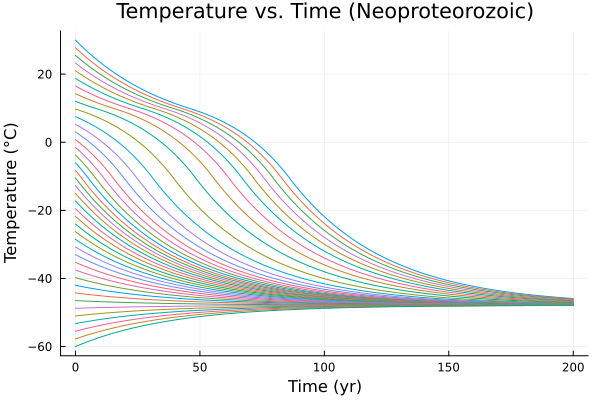

In [112]:
#this function computes the increment by which the temperature is updated at every step
function simulate_timestep(T, C, S, a_i, a_0, A, B)
    if T < -10
        return ((1/C) * ((S/4)*(1-a_i) - A + B*T))
    end

    if T > 10
        return ((1/C) * ((S/4)*(1-a_0) - A + B*T))
    end

    return ((1/C) * ((S/4)*(1-(a_i+(a_0-a_i)*((T+10)/20))) - A + B*T))
end
#result = simulate_timestep(-20,51,1272,0.5,0.3,221.2,-1.3)

#This function loops over the timesteps to simulate the temperature series
function temperature_simulate(T_0, C, S, a_i, a_0, A, B, total_time, delta_t)
    #initialize T storage
    #array length is T+1
    #index 1 it T_0
    steps = Int64(total_time / delta_t)
    T = zeros(steps + 1)
    T[1] = T_0
    for t = 1:steps
        T[t+1] = T[t] + 
            delta_t * simulate_timestep(T[t], C, S, a_i, a_0, A, B)
    end
    #the first element of T is the initial condition
    return T
end

delta_t = 1
total_time = 200
T_0 = 11
C = 51
S = 1272
a_i = 0.5
a_0 = 0.3
A = 221.2
B = -1.3
#T = temperature_simulate(T_0, C, S, a_i, a_0, A, B, total_time, delta_t)

p1 = plot(; xlabel="Time (yr)", ylabel="Temperature (°C)", title = "Temperature vs. Time (Neoproteorozoic)")

#test = 30
for i in 1:41
    T = temperature_simulate((32.25 - 2.25*i), C, S, a_i, a_0, A, B, total_time, delta_t)
    plot!(p1, 0:delta_t:total_time, T, label = "")
end

#plot!(p1, )
display(p1)



--> The plot above shows the simulated change in temperature over the course 200 years during the Neoproteorozoic period with 40 varying initial values of T between 30°C and -60°C. This model uses the piecewise function for albedo which is sometimes constant and sometimes temperature-variable at certain values of T. Since this graph depicts the Neoproteotozoic period, I used a Solar constant value of $1272 W/m^2$.

--> There is only one Equilibrium for this system for the given range of temperature values: it is a stable equilibrium at about -49°C. The odd shape of the plot lines between T values of -10°C and 10°C is due to the value of albedo being non-constant within that range, not because of the existence of an unstable equilibrium near there.

--> Description of code: I converted the discretized model for the change in temperature over time into a function which I then iterated at each timestep to generate the next value in the 200-year array of temperature values. I then used a for loop to plot a specific number of graph lines on the pre-existing plot with equally spaced, varying initial temperature conditions.

#### Problem 3.3

One might hypothesize that one cause for the transition from Snowball
Earth (the stable frozen equilibrium from Problem 3.2) was an increasing
amount of incoming solar radiation (as expressed by an increase in $S$).
Examine this hypothesis using our simple model. Is this factor enough to
cause the planet to warm to the pre-industrial temperature of
$14^\circ\text{C}$?

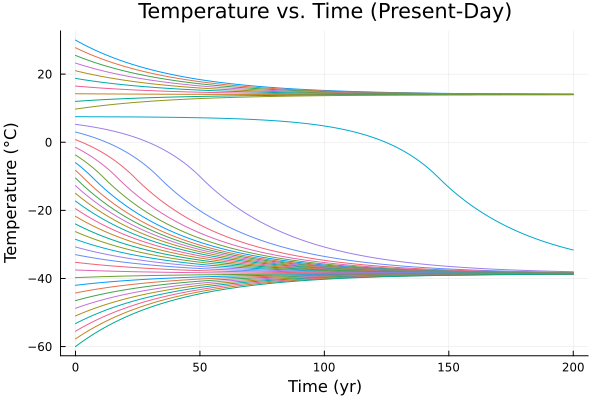

In [114]:
delta_t = 1
total_time = 200
T_0 = 11
C = 51
S = 1368
a_i = 0.5
a_0 = 0.3
A = 221.2
B = -1.3
#T = temperature_simulate(T_0, C, S, a_i, a_0, A, B, total_time, delta_t)

p2 = plot(; xlabel="Time (yr)", ylabel="Temperature (°C)", title = "Temperature vs. Time (Present-Day)")

for i in 1:41
    T = temperature_simulate((32.25 - 2.25*i), C, S, a_i, a_0, A, B, total_time, delta_t)
    plot!(p2, 0:delta_t:total_time, T, label = "")
end

display(p2)

--> The plot above shows the simulated change in temperature over the course 200 years during the Present-Day with 40 varying initial values of T between 30°C and -60°C. This model uses the piecewise function for albedo which is sometimes constant and sometimes temperature-variable at certain values of T. Since this graph depicts the Neoproteotozoic period, I used a Solar constant value of $1368 W/m^2$.

--> There are three equilibria for this system within the given range of temperature values: a stable equilibrium at about 14°C, an unstable equilibrium at about 7°C, and a second stable equilibrium at about -40°C.

--> Description of code: I used the same code as in Problem 3.2, but changed the value of the Solar constant to $1368 W/m^2$.

--> This graph result shows that as the solar constant increased from $1272W/m^2$ to its present day value of $1368W/m^2$, a new stable equilibria appeared at about 14°C which is a temperature range habitable to life. So yes the changing solar constant does explain how the earth is able to avoid turning into a snowball in the present-day, assuming our temperature model is accurate. But it does not explain how the earth's temperature warmed from its stable Neoproteorozoic temperature of about -48°C. Some other stimulus would have had to warm the earth up past the unstable equilibrium value of about 7°C in order for the earth to enter the much warmer stable equilibrium.

## References

List any external references consulted, including classmates.

--> I consulted stack Exchange and online Julia forums while debugging my plots. I did not work with any other classmates.